<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: Build Region Masks</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Load GADM state boundaries, group into 4 regions, dissolve into region polygons, and compute fractional area-overlap weights against the MPI-GE grid.</p>
</div>

In [1]:
import xarray as xr
import geopandas as gpd
import regionmask
import numpy as np

In [2]:
# Point to the folder where the 6 already-extracted MPI-GE files are saved.
# No re-running of any extraction here, just loading a saved file
# to get the lat/lon grid, which the masks need to be built on.
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'

# Load one file (rx5day_ant)
rx5day_ant = xr.open_dataset(OUTPUT_DIR + 'rx5day_jjas_ant_all.nc')

print(rx5day_ant)

<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 15, lon: 16, year: 165, member: 30)
Coordinates:
  * lat      (lat) float64 120B 8.394 10.26 12.12 13.99 ... 30.78 32.64 34.51
  * lon      (lon) float64 128B 69.38 71.25 73.12 75.0 ... 93.75 95.62 97.5
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * member   (member) <U9 1kB 'r1i1p1f1' 'r2i1p1f1' ... 'r29i1p1f1' 'r30i1p1f1'
Data variables:
    rx5day   (member, year, lat, lon) float32 5MB ...


Number of dissolved states/UTs: 36


<Axes: >

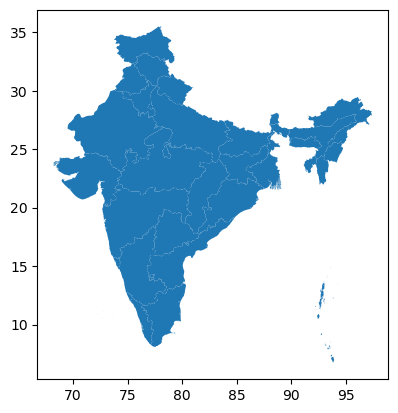

In [3]:
# Load the GADM Level-1 (state/UT) shapefile for India
path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")

# GADM splits some states into multiple rows for disputed-territory reasons
# (e.g. Arunachal Pradesh, J&K, Uttarakhand). Dissolve by state name so each state becomes a single clean polygon.
gdf_clean = gdf.dissolve(by="NAME_1")

# Sanity check for 36 states/UTs, and the map should look like a complete India
print(f'Number of dissolved states/UTs: {len(gdf_clean)}')
gdf_clean.plot()

In [4]:
# Define which states belong to each of the 4 dissertation regions.
# NOTE: Maharashtra is assigned whole-state to Western_Ghats (not split
# coastal/interior) because CWC flood damage data is only reported at
# state level (there's no way to calibrate f(R) on a sub-state split)
# NOTE: Jharkhand added to Central_India, shares continental/convective
# flash-flood regime, fills the geographic gap between IGP and Central India.
region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana', 'NCT of Delhi'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}

state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)

print(gdf_clean['region'].value_counts(dropna=False))
print('\nUnassigned states (expected -- not in any of the 4 regions):')
print(gdf_clean[gdf_clean['region'].isna()].index.tolist())

all_listed_states = [s for states in region_states.values() for s in states]
matched_states = gdf_clean[gdf_clean['region'].notna()].index.tolist()
missing = set(all_listed_states) - set(matched_states)
print(f'\nStates in region_states but NOT found in GADM index (should be empty!): {missing}')

region
NaN                    18
Indo_Gangetic_Plain     6
Northeast               4
Central_India           4
Western_Ghats           4
Name: count, dtype: int64

Unassigned states (expected -- not in any of the 4 regions):
['Andaman and Nicobar', 'Andhra Pradesh', 'Chandigarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Gujarat', 'Himachal Pradesh', 'Jammu and Kashmir', 'Lakshadweep', 'Manipur', 'Mizoram', 'Nagaland', 'Puducherry', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Uttarakhand']

States in region_states but NOT found in GADM index (should be empty!): set()


['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']


<Axes: >

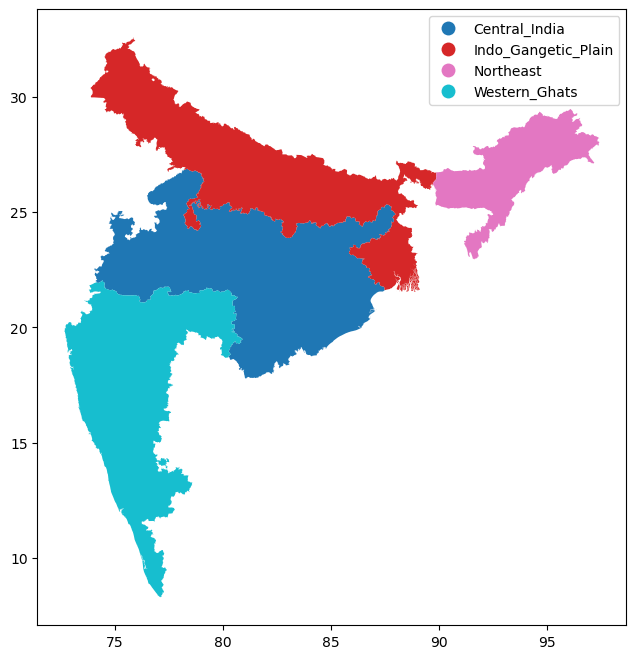

In [5]:
# Merge the individual state polygons within each region into a single
# combined polygon per region (4 polygons/regions total)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

# Check we have 4 regions, and visually confirm the shapes look alright
print(gdf_regions.index.tolist())
gdf_regions.reset_index().plot(column='region', legend=True, figsize=(8,8))

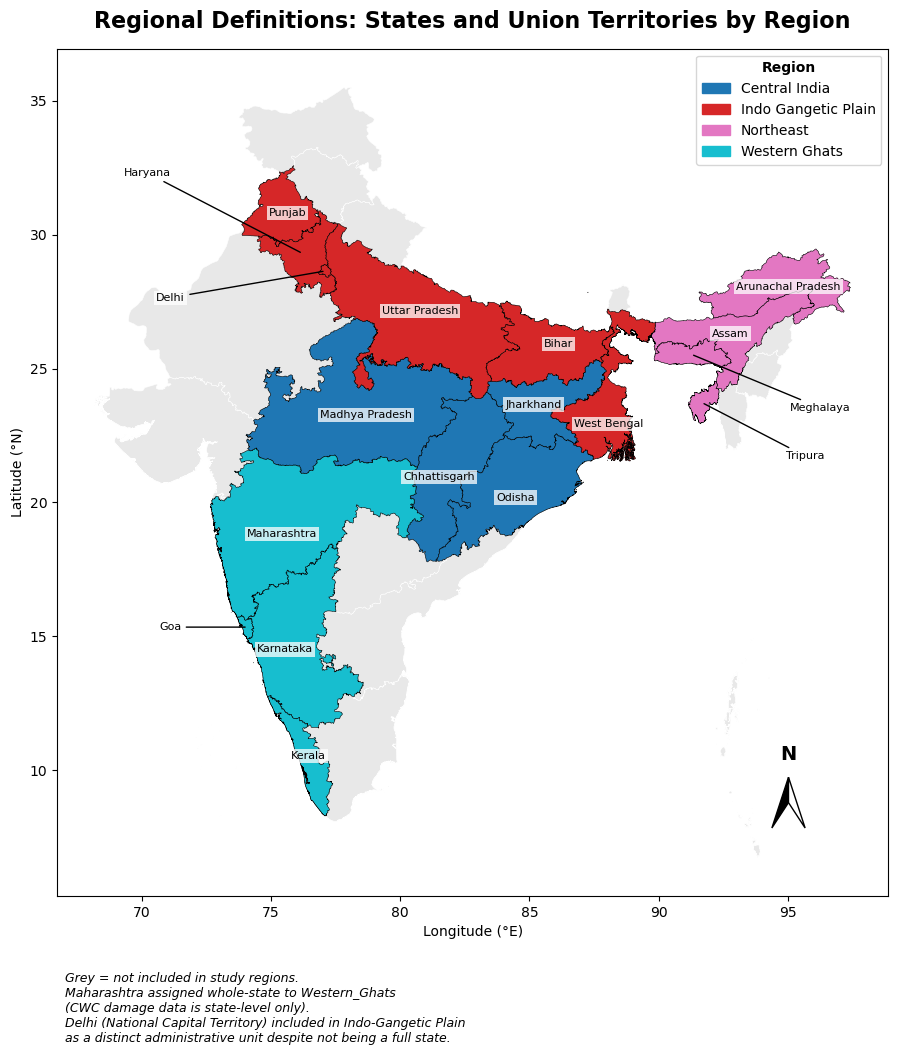

In [6]:
# Regional reference map
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

region_colors = {
    'Central_India': '#1f77b4',
    'Indo_Gangetic_Plain': '#d62728',
    'Northeast': '#e377c2',
    'Western_Ghats': '#17becf',
}

# leader lines for states too small/narrow for an inline label 
LEADER_OFFSETS = {
    'Haryana': (-6, 3),
    'Goa': (-3, 0),
    'Tripura': (4, -2),
    'Meghalaya': (5, -2),
    'NCT of Delhi': (-6, -1),
}

# Display cleaner common names on the map
DISPLAY_NAMES = {'NCT of Delhi': 'Delhi'}

label_style = dict(fontsize=8, fontweight='normal', color='black', ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5))

fig, ax = plt.subplots(figsize=(11, 11))

gdf_clean.plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.4)

study = gdf_clean[gdf_clean['region'].notna()]
for region, color in region_colors.items():
    study[study['region'] == region].plot(
        ax=ax, color=color, edgecolor='black', linewidth=0.4)

# Small nudges for inline labels that don't need a leader line, but sit awkwardly at their current position
LABEL_OFFSETS = {
    'West Bengal': (0, -1.5),
    'Assam': (2, 0.25),
    'Karnataka': (0, -0.5),
    'Punjab': (0, -0.25),
    'Madhya Pradesh': (-0.7, -0.7),
}

for state, row in study.iterrows():
    pt = row.geometry.representative_point()
    label_text = DISPLAY_NAMES.get(state, state)
    if state in LEADER_OFFSETS:
        dx, dy = LEADER_OFFSETS[state]
        ax.annotate(label_text, xy=(pt.x, pt.y), xytext=(pt.x + dx, pt.y + dy),
                    arrowprops=dict(arrowstyle='-', color='black', lw=1),
                    **label_style)
    elif state in LABEL_OFFSETS:
        dx, dy = LABEL_OFFSETS[state]
        ax.annotate(label_text, xy=(pt.x + dx, pt.y + dy), **label_style)
    else:
        ax.annotate(label_text, xy=(pt.x, pt.y), **label_style)

handles = [mpatches.Patch(color=c, label=r.replace('_', ' '))
           for r, c in region_colors.items()]
ax.legend(handles=handles, title='Region', title_fontproperties={'weight': 'bold'}, loc='upper right', fontsize=10, frameon=True)

ax.set_title('Regional Definitions: States and Union Territories by Region', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.text(0.01, -0.09,
        'Grey = not included in study regions.\n'
        'Maharashtra assigned whole-state to Western_Ghats\n'
        '(CWC damage data is state-level only).\n'
        'Delhi (National Capital Territory) included in Indo-Gangetic Plain\n'
        'as a distinct administrative unit despite not being a full state.',
        transform=ax.transAxes, fontsize=9, style='italic', va='top')


#North Arrow
from matplotlib.patches import Polygon

x, y = 0.88, 0.08
h = 0.06
w = 0.02

# Black north half
north = Polygon(
    [
        (x, y+h),
        (x-w, y),
        (x, y+0.03),
    ],
    transform=ax.transAxes,
    facecolor='black',
    edgecolor='black'
)

# White south half
south = Polygon(
    [
        (x, y+h),
        (x+w, y),
        (x, y+0.03),
    ],
    transform=ax.transAxes,
    facecolor='white',
    edgecolor='black'
)

ax.add_patch(north)
ax.add_patch(south)

ax.text(
    x,
    y+h+0.02,
    "N",
    transform=ax.transAxes,
    ha='center',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(OUTPUT_DIR + 'regional_reference_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Build a regionmask object from the 4 dissolved region polygons.
region_names = gdf_regions.index.tolist()
regions_mask_obj = regionmask.Regions(
    gdf_regions.geometry.tolist(),
    names=region_names,
    abbrevs=[r[:3] for r in region_names]
)

# Get the MPI-GE grid's lat/lon coordinates (loaded back in Cell 2)
lat = rx5day_ant.lat.values
lon = rx5day_ant.lon.values

# Compute the fractional overlap of each grid cell with each region.
frac_overlap = regions_mask_obj.mask_3D_frac_approx(lon, lat)
frac_overlap = frac_overlap.assign_coords(region=region_names)  # Attach region names as labels
print(frac_overlap)

<xarray.DataArray 'mask' (region: 4, lat: 15, lon: 16)> Size: 8kB
array([[[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.17, 0.22, 0.  , 0.  ,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.57, 0.98, 0.76, 0.26,
         0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.4 , 0.5 , 0.45, 0.75, 1.  , 1.  , 0.87,
         0.01, 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  ,

In [8]:
# For each region, sum the fractional weights across all grid cells
# This approximates each region's total area within the MPI-GE grid
region_weight_sum = frac_overlap.sum(dim=['lat', 'lon'])
print(region_weight_sum)

# Also count grid cells with meaningful overlap (e.g. >10%) per region
# This will matter for how many cells will feed into my GEV fitting per region
meaningful_overlap = (frac_overlap > 0.1).sum(dim=['lat', 'lon'])
print('\nGrid cells with >10% overlap per region:')
print(meaningful_overlap)

<xarray.DataArray 'mask' (region: 4)> Size: 32B
array([16.87, 13.46,  5.06, 13.16])
Coordinates:
    abbrevs  (region) <U3 48B 'Cen' 'Ind' 'Nor' 'Wes'
    names    (region) <U19 304B 'Central_India' ... 'Western_Ghats'
  * region   (region) <U19 304B 'Central_India' ... 'Western_Ghats'

Grid cells with >10% overlap per region:
<xarray.DataArray 'mask' (region: 4)> Size: 32B
array([29, 24, 10, 22])
Coordinates:
    abbrevs  (region) <U3 48B 'Cen' 'Ind' 'Nor' 'Wes'
    names    (region) <U19 304B 'Central_India' ... 'Western_Ghats'
  * region   (region) <U19 304B 'Central_India' ... 'Western_Ghats'


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Apply Region Masks to MPI-GE Data</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Compute area-weighted regional Rx5day time series (member x year x region) using the fractional overlap weights ('frac_overlap') built in Part 1.</p>
</div>

In [9]:
# Apply the area-fraction region masks to compute regional Rx5day time series.
# For each region, multiply every grid cell's value by its fractional overlap
# weight, then sum and divide by the total weight. This is the area-weighted
# regional average, following the standard aggregation scheme from the literature.

def compute_regional_series(data, frac_overlap):
    """
    data: xr.DataArray with dims (member, year, lat, lon)
    frac_overlap: xr.DataArray with dims (region, lat, lon), fractional weights

    Returns: xr.DataArray with dims (region, member, year)
    """
    # Weighted sum across lat/lon, then normalize by total weight per region
    weighted_sum = (data * frac_overlap).sum(dim=['lat', 'lon'])
    weight_total = frac_overlap.sum(dim=['lat', 'lon'])
    regional_avg = weighted_sum / weight_total
    return regional_avg

# Apply to the rx5day_ant data already loaded
rx5day_ant_regional = compute_regional_series(rx5day_ant['rx5day'], frac_overlap)

print(rx5day_ant_regional)
print('\nMean Rx5day per region (sanity check):')
print(rx5day_ant_regional.mean(dim=['member', 'year']))

<xarray.DataArray (member: 30, year: 165, region: 4)> Size: 158kB
array([[[117.63903933,  98.03385749, 141.17522269,  96.02634981],
        [126.14301045,  99.52118915, 137.25716519,  91.33540576],
        [125.19968594,  96.7934649 , 116.65325744, 106.65589046],
        ...,
        [108.57928115,  99.59755523, 134.28763592,  72.93503891],
        [130.02910484, 110.40931439, 128.69275368, 100.80960748],
        [108.37190778,  93.6041574 , 119.84664686, 112.4747001 ]],

       [[109.7947017 ,  97.40642876, 136.82435861,  92.55894354],
        [111.96020724,  94.6578588 , 151.74249067, 108.81890916],
        [122.92496384, 110.73934508, 149.44262493,  94.11023671],
        ...,
        [136.80582444,  93.733327  , 118.55563917,  93.57490985],
        [119.01716024,  99.06242492, 112.26928079,  98.7496095 ],
        [110.27056336,  99.12807188, 157.04177783,  74.43461022]],

       [[134.6105178 ,  91.91971603, 116.50287179,  89.24349924],
        [110.91601209,  98.75780985, 123.31668

In [10]:
# Apply the regional masking to MPI-GE files 
# confirmed unused downstream throughout this project)

# Load the remaining 2 files (rx5day_ant already loaded earlier)
rx5day_nat = xr.open_dataset(OUTPUT_DIR + 'rx5day_jjas_nat_all.nc')
rx5day_ssp245 = xr.open_dataset(OUTPUT_DIR + 'rx5day_jjas_ssp245_all.nc')

# Apply the same regional aggregation function to each
rx5day_nat_regional = compute_regional_series(rx5day_nat['rx5day'], frac_overlap)
rx5day_ssp245_regional = compute_regional_series(rx5day_ssp245['rx5day'], frac_overlap)

# Check: Print mean per region for each
for name, da in [
    ('rx5day_ant', rx5day_ant_regional), ('rx5day_nat', rx5day_nat_regional),
    ('rx5day_ssp245', rx5day_ssp245_regional)
]:
    print(f'{name}: {da.mean(dim=["member","year"]).values}')

rx5day_ant: [118.6359734   96.62701422 142.87458721  91.54784093]
rx5day_nat: [118.25531135  96.43862322 141.84313847  90.71918006]
rx5day_ssp245: [126.63940717 103.29057382 148.38511496  94.82115058]


In [11]:
# Save regional time series to disk for later use 
regional_datasets = {
    'rx5day_ant_regional': rx5day_ant_regional,
    'rx5day_nat_regional': rx5day_nat_regional,
    'rx5day_ssp245_regional': rx5day_ssp245_regional,
}

for name, da in regional_datasets.items():
    da.name = name
    da.to_netcdf(OUTPUT_DIR + f'{name}.nc')
    print(f'Saved {name}.nc')

Saved rx5day_ant_regional.nc
Saved rx5day_nat_regional.nc
Saved rx5day_ssp245_regional.nc


In [12]:
# Check whether the outlier grid cell (18.25N, 68.5E) falls inside any of our
# 4 regions by looking up its fractional weight in frac_overlap.
# NOTE: frac_overlap was built on the MPI-GE grid, not ERA5, so need to
# check the nearest MPI-GE grid cell to 18.25N, 68.5E instead.

# Find the nearest MPI-GE grid cell to the outlier location
outlier_lat = 18.25
outlier_lon = 68.5

# Select nearest grid cell in frac_overlap
weights_at_outlier = frac_overlap.sel(lat=outlier_lat, lon=outlier_lon, method='nearest')

print(f'Nearest MPI-GE grid cell to outlier ({outlier_lat}N, {outlier_lon}E):')
print(f'  lat: {float(frac_overlap.lat.sel(lat=outlier_lat, method="nearest")):.3f}')
print(f'  lon: {float(frac_overlap.lon.sel(lon=outlier_lon, method="nearest")):.3f}')
print(f'\nFractional overlap with each region:')
for i, name in enumerate(frac_overlap.names.values):
    print(f'  {name}: {float(weights_at_outlier[i]):.3f}')

Nearest MPI-GE grid cell to outlier (18.25N, 68.5E):
  lat: 17.720
  lon: 69.375

Fractional overlap with each region:
  Central_India: 0.000
  Indo_Gangetic_Plain: 0.000
  Northeast: 0.000
  Western_Ghats: 0.000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: Apply Region Masks to ERA5 Grid</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Same region polygons as Part 1, but rasterized onto the finer ERA5 grid (0.25°) rather than the course MPI-GE grid (1.875°).</p>
</div>

In [13]:
# Load the ERA5 file to get lat/lon grid and data
ERA5_OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
rx5day_era5 = xr.open_dataset(ERA5_OUTPUT_DIR + 'rx5day_jjas_era5_1981_2023.nc')

lat_era5 = rx5day_era5.latitude.values
lon_era5 = rx5day_era5.longitude.values

print(f'ERA5 grid: {len(lat_era5)} lat x {len(lon_era5)} lon')
print(f'Lat range: {lat_era5.min():.2f} to {lat_era5.max():.2f}')
print(f'Lon range: {lon_era5.min():.2f} to {lon_era5.max():.2f}')

frac_overlap_era5 = regions_mask_obj.mask_3D_frac_approx(lon_era5, lat_era5)
frac_overlap_era5 = frac_overlap_era5.assign_coords(region=region_names)

print(f'\nERA5 mask shape: {dict(frac_overlap_era5.sizes)}')
print('\nWeighted cell sum per region (ERA5):')
print(frac_overlap_era5.sum(dim=['lat', 'lon']))

ERA5 grid: 129 lat x 129 lon
Lat range: 5.00 to 37.00
Lon range: 67.00 to 99.00

ERA5 mask shape: {'region': 4, 'lat': 129, 'lon': 129}

Weighted cell sum per region (ERA5):
<xarray.DataArray 'mask' (region: 4)> Size: 32B
array([953.57, 750.33, 281.14, 735.17])
Coordinates:
    abbrevs  (region) <U3 48B 'Cen' 'Ind' 'Nor' 'Wes'
    names    (region) <U19 304B 'Central_India' ... 'Western_Ghats'
  * region   (region) <U19 304B 'Central_India' ... 'Western_Ghats'


In [15]:
# Fix 1: rename ERA5 dimension names to match frac_overlap (lat/lon not latitude/longitude)
rx5day_era5_data = rx5day_era5['rx5day'].rename({'latitude': 'lat', 'longitude': 'lon'})

# Fix 2: process year by year to avoid errors
def compute_regional_series_era5(data, frac_overlap):
    """
    data: xr.DataArray with dims (year, lat, lon)
    frac_overlap: xr.DataArray with dims (region, lat, lon)
    Returns: xr.DataArray with dims (year, region)
    """
    weight_total = frac_overlap.sum(dim=['lat', 'lon'])
    results = []
    for yr in data.year.values:
        yr_data = data.sel(year=yr)
        weighted = (yr_data * frac_overlap).sum(dim=['lat', 'lon'])
        results.append(weighted / weight_total)
    return xr.concat(results, dim='year').assign_coords(year=data.year.values)

rx5day_era5_regional = compute_regional_series_era5(rx5day_era5_data, frac_overlap_era5)

print('Mean Rx5day per region (ERA5):')
print(rx5day_era5_regional.mean(dim='year').values)

Mean Rx5day per region (ERA5):
[191.32656007 160.14480255 273.08011985 172.77437233]


In [16]:
# Save ERA5 regional time series
rx5day_era5_regional.name = 'rx5day'

rx5day_era5_regional.to_netcdf(ERA5_OUTPUT_DIR + 'rx5day_era5_regional.nc')

print('Saved rx5day_era5_regional.nc')

Saved rx5day_era5_regional.nc


In [17]:
print("ant:", int(rx5day_ant.year.min()), "-", int(rx5day_ant.year.max()))
print("nat:", int(rx5day_nat.year.min()), "-", int(rx5day_nat.year.max()))

ant: 1850 - 2014
nat: 1850 - 2014


In [18]:
print("MPI region mask check")
print("frac_overlap dims:", dict(frac_overlap.sizes))
print("frac_overlap lat range:", float(frac_overlap.lat.min()), "to", float(frac_overlap.lat.max()))
print("frac_overlap lon range:", float(frac_overlap.lon.min()), "to", float(frac_overlap.lon.max()))
print()
print("Total weight captured per region (MPI grid):")
for region in region_names:
    print(f"  {region}: {float(frac_overlap.sel(region=region).sum()):.2f}")

print("\nMPI regional Rx5day series check")
for name, ds in [('ant', rx5day_ant_regional), ('nat', rx5day_nat_regional), ('ssp245', rx5day_ssp245_regional)]:
    print(f"{name}: shape {dict(ds.sizes)}, mean {float(ds.mean()):.1f} mm")

print("\nERA5 region mask check")
print("frac_overlap_era5 dims:", dict(frac_overlap_era5.sizes))
print("frac_overlap_era5 lat range:", float(frac_overlap_era5.lat.min()), "to", float(frac_overlap_era5.lat.max()))
print("frac_overlap_era5 lon range:", float(frac_overlap_era5.lon.min()), "to", float(frac_overlap_era5.lon.max()))
print()
print("Total weight captured per region (ERA5 grid):")
for region in region_names:
    print(f"  {region}: {float(frac_overlap_era5.sel(region=region).sum()):.2f}")

print("\nERA5 regional Rx5day series check")
print(f"rx5day_era5_regional: shape {dict(rx5day_era5_regional.sizes)}, mean {float(rx5day_era5_regional.mean()):.1f} mm")

MPI region mask check
frac_overlap dims: {'region': 4, 'lat': 15, 'lon': 16}
frac_overlap lat range: 8.393668907692383 to 34.50724334150103
frac_overlap lon range: 69.375 to 97.5

Total weight captured per region (MPI grid):
  Central_India: 16.87
  Indo_Gangetic_Plain: 13.46
  Northeast: 5.06
  Western_Ghats: 13.16

MPI regional Rx5day series check
ant: shape {'member': 30, 'year': 165, 'region': 4}, mean 112.4 mm
nat: shape {'member': 30, 'year': 165, 'region': 4}, mean 111.8 mm
ssp245: shape {'member': 30, 'year': 86, 'region': 4}, mean 118.3 mm

ERA5 region mask check
frac_overlap_era5 dims: {'region': 4, 'lat': 129, 'lon': 129}
frac_overlap_era5 lat range: 5.0 to 37.0
frac_overlap_era5 lon range: 67.0 to 99.0

Total weight captured per region (ERA5 grid):
  Central_India: 953.57
  Indo_Gangetic_Plain: 750.33
  Northeast: 281.14
  Western_Ghats: 735.17

ERA5 regional Rx5day series check
rx5day_era5_regional: shape {'year': 43, 'region': 4}, mean 199.3 mm
